# Notebook 06: Anomaly Detection
Identifies unusual orders and patterns using IQR, Z-score, and combined flagging methods.
Investigates the May 2016 residual spike found in time series decomposition.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 150
os.makedirs("../outputs/figures", exist_ok=True)

# Load cleaned data
df = pd.read_csv("../data/processed/cleaned_data.csv", encoding="latin-1")
df["Order Date"] = pd.to_datetime(df["Order Date"])

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (9994, 31)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month', 'Quarter', 'MonthName', 'DayOfWeek', 'YearMonth', 'DaysToShip', 'ProfitMargin', 'HighDiscount', 'SalesOutlier']


In [2]:
# METHOD 1: IQR-based anomaly detection on Sales
Q1_s = df["Sales"].quantile(0.25)
Q3_s = df["Sales"].quantile(0.75)
IQR_s = Q3_s - Q1_s
upper_s = Q3_s + 1.5 * IQR_s

# METHOD 2: Z-score on Profit
df["Profit_Zscore"] = (df["Profit"] - df["Profit"].mean()) / df["Profit"].std()

# METHOD 3: Combined flag — high discount AND negative profit
df["Anomaly_HighDiscount_Loss"] = (df["Discount"] >= 0.4) & (df["Profit"] < 0)

# METHOD 4: Sales outlier (already computed in cleaning notebook)
# Using SalesOutlier column already in df

# Master anomaly flag — triggered by ANY method
df["IsAnomaly"] = (
    (df["Sales"] > upper_s) |
    (df["Profit_Zscore"].abs() > 2.5) |
    (df["Anomaly_HighDiscount_Loss"])
)

print(f"IQR Sales upper bound:        ${upper_s:,.2f}")
print(f"Profit Z-score threshold:     ±2.5")
print(f"High discount + loss orders:  {df['Anomaly_HighDiscount_Loss'].sum()}")
print(f"\nTotal anomalies flagged:      {df['IsAnomaly'].sum()}")
print(f"As % of all orders:           {df['IsAnomaly'].mean():.1%}")

IQR Sales upper bound:        $498.93
Profit Z-score threshold:     ±2.5
High discount + loss orders:  1113

Total anomalies flagged:      2175
As % of all orders:           21.8%


In [3]:
# Anomaly breakdown by category
print("Anomalies by Category:")
print(df[df["IsAnomaly"]].groupby("Category")["IsAnomaly"].count())

print("\nAnomalies by detection method:")
print(f"  Sales IQR outliers:          {(df['Sales'] > upper_s).sum()}")
print(f"  Profit Z-score outliers:     {(df['Profit_Zscore'].abs() > 2.5).sum()}")
print(f"  High discount + loss:        {df['Anomaly_HighDiscount_Loss'].sum()}")

print("\nTop 10 anomalous orders by Sales:")
top_anomalies = (df[df["IsAnomaly"]]
                 .sort_values("Sales", ascending=False)
                 [["Order ID","Product Name","Sales","Profit","Discount","Category"]]
                 .head(10))
print(top_anomalies.to_string(index=False))

Anomalies by Category:
Category
Furniture          716
Office Supplies    960
Technology         499
Name: IsAnomaly, dtype: int64

Anomalies by detection method:
  Sales IQR outliers:          1167
  Profit Z-score outliers:     136
  High discount + loss:        1113

Top 10 anomalous orders by Sales:
      Order ID                                              Product Name     Sales     Profit  Discount        Category
CA-2014-145317     Cisco TelePresence System EX90 Videoconferencing Unit 22638.480 -1811.0784       0.5      Technology
CA-2016-118689                     Canon imageCLASS 2200 Advanced Copier 17499.950  8399.9760       0.0      Technology
CA-2017-140151                     Canon imageCLASS 2200 Advanced Copier 13999.960  6719.9808       0.0      Technology
CA-2017-127180                     Canon imageCLASS 2200 Advanced Copier 11199.968  3919.9888       0.2      Technology
CA-2017-166709                     Canon imageCLASS 2200 Advanced Copier 10499.970  5039.9856  

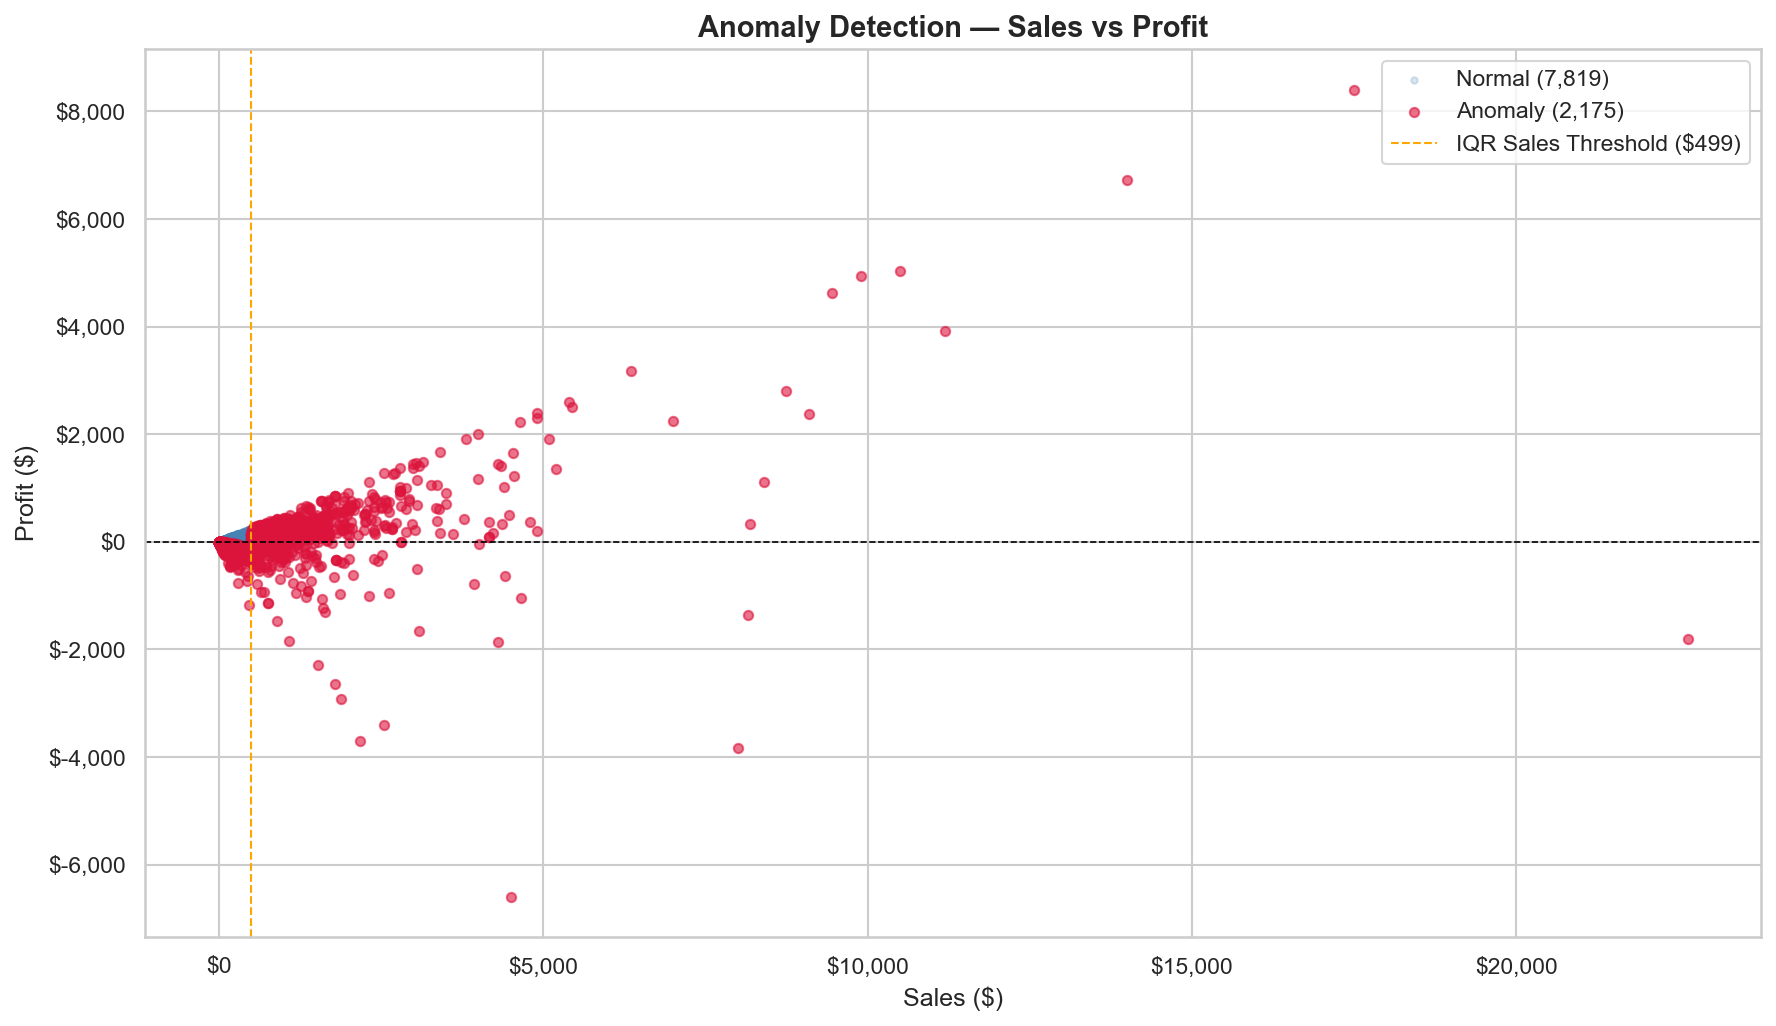

Saved.


In [4]:
# Visualise anomalies — Sales vs Profit scatter
fig, ax = plt.subplots(figsize=(12, 7))

normal = df[~df["IsAnomaly"]]
anomalies = df[df["IsAnomaly"]]

ax.scatter(normal["Sales"], normal["Profit"],
           alpha=0.2, s=10, color="steelblue", label=f"Normal ({len(normal):,})")
ax.scatter(anomalies["Sales"], anomalies["Profit"],
           alpha=0.6, s=20, color="crimson", label=f"Anomaly ({len(anomalies):,})")

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.axvline(upper_s, color="orange", linewidth=1, linestyle="--", label=f"IQR Sales Threshold (${upper_s:,.0f})")
ax.set_title("Anomaly Detection — Sales vs Profit", fontsize=14, fontweight="bold")
ax.set_xlabel("Sales ($)")
ax.set_ylabel("Profit ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/anomaly_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

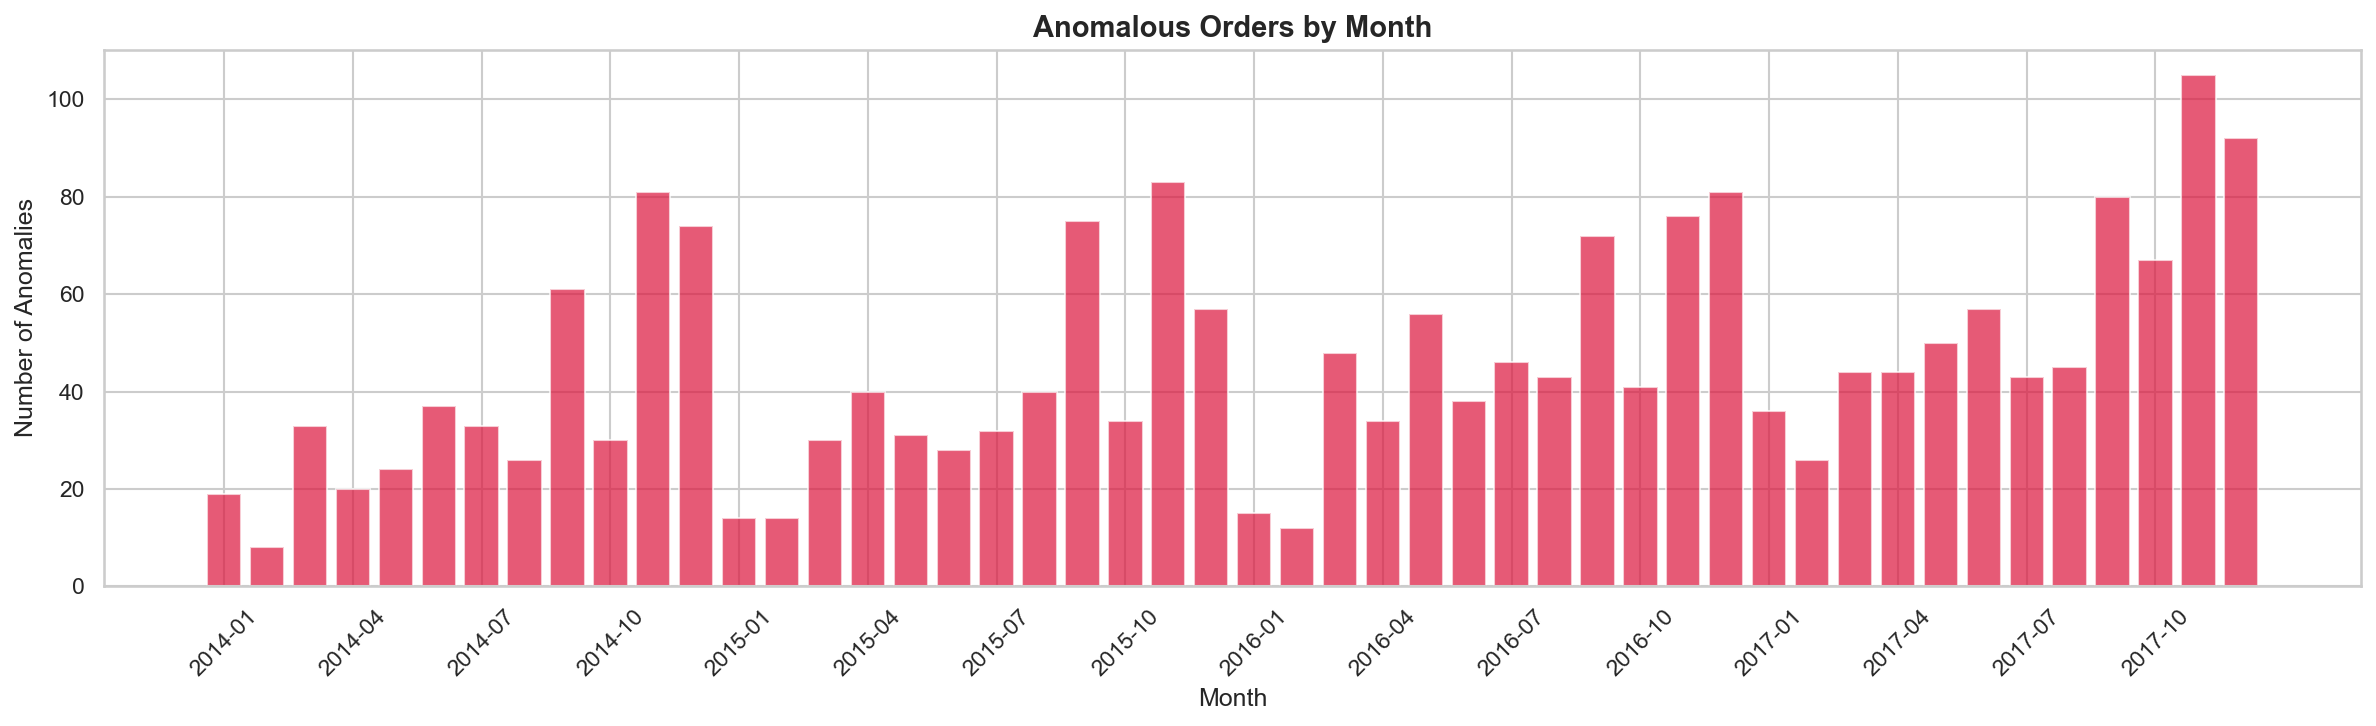

Saved.


In [5]:
# Anomalies over time — how are they distributed across months?
anomaly_monthly = (df[df["IsAnomaly"]]
                   .groupby(df["Order Date"].dt.to_period("M"))
                   .size()
                   .reset_index())
anomaly_monthly.columns = ["YearMonth", "Count"]
anomaly_monthly["YearMonth"] = anomaly_monthly["YearMonth"].astype(str)

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(anomaly_monthly["YearMonth"], anomaly_monthly["Count"],
       color="crimson", alpha=0.7, edgecolor="white")
ax.set_title("Anomalous Orders by Month", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Anomalies")
tick_positions = list(range(0, len(anomaly_monthly), 3))
ax.set_xticks(tick_positions)
ax.set_xticklabels([anomaly_monthly["YearMonth"].iloc[i] for i in tick_positions], rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/anomaly_timeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [6]:
# Investigate May 2016 spike found in decomposition residuals
may_2016 = df[(df["Order Date"].dt.year == 2016) & (df["Order Date"].dt.month == 5)]

print(f"May 2016 orders: {len(may_2016)}")
print(f"May 2016 total sales: ${may_2016['Sales'].sum():,.2f}")
print(f"May 2016 anomalous orders: {may_2016['IsAnomaly'].sum()}")
print(f"\nTop orders in May 2016 by Sales:")
print(may_2016.sort_values("Sales", ascending=False)
      [["Order ID","Product Name","Sales","Profit","Discount","Category"]]
      .head(10).to_string(index=False))

May 2016 orders: 225
May 2016 total sales: $56,987.73
May 2016 anomalous orders: 56

Top orders in May 2016 by Sales:
      Order ID                                                       Product Name    Sales    Profit  Discount        Category
CA-2016-143714                              Canon imageCLASS 2200 Advanced Copier 8399.976 1119.9968       0.4      Technology
CA-2016-128818                                        Bady BDG101FRU Card Printer 3999.950 1159.9855       0.0      Technology
CA-2016-122903                       HON 5400 Series Task Chairs for Big and Tall 3504.900  700.9800       0.0       Furniture
CA-2016-107202                          Panasonic KX MB2061 Multifunction Printer 2396.400  179.7300       0.2      Technology
CA-2016-113831                                  Hon Rectangular Conference Tables 2275.500  386.8350       0.0       Furniture
CA-2016-133725                                       Mitel MiVoice 5330e IP Phone 1979.928  148.4946       0.2      Tech

In [7]:
# High discount loss analysis — the most actionable business insight
high_disc_loss = df[df["Anomaly_HighDiscount_Loss"]].copy()

print(f"Orders with ≥40% discount AND negative profit: {len(high_disc_loss)}")
print(f"Total revenue lost on these orders: ${high_disc_loss['Profit'].sum():,.2f}")

print("\nBy Category:")
print(high_disc_loss.groupby("Category")[["Sales","Profit"]].sum().round(2))

print("\nBy Sub-Category (top loss makers):")
subcat = (high_disc_loss.groupby("Sub-Category")["Profit"]
          .sum().sort_values().head(8).round(2))
print(subcat)

print("\nDiscount distribution on loss orders:")
print(high_disc_loss["Discount"].value_counts().sort_index())

Orders with ≥40% discount AND negative profit: 1113
Total revenue lost on these orders: $-125,346.42

By Category:
                     Sales    Profit
Category                            
Furniture         81186.93 -41391.30
Office Supplies   39523.15 -47140.14
Technology       103072.51 -36814.98

By Sub-Category (top loss makers):
Sub-Category
Binders       -38510.50
Machines      -30099.20
Tables        -27295.90
Appliances     -8629.64
Bookcases      -8150.75
Phones         -6715.78
Furnishings    -5944.66
Name: Profit, dtype: float64

Discount distribution on loss orders:
Discount
0.40    180
0.45     11
0.50     66
0.60    138
0.70    418
0.80    300
Name: count, dtype: int64


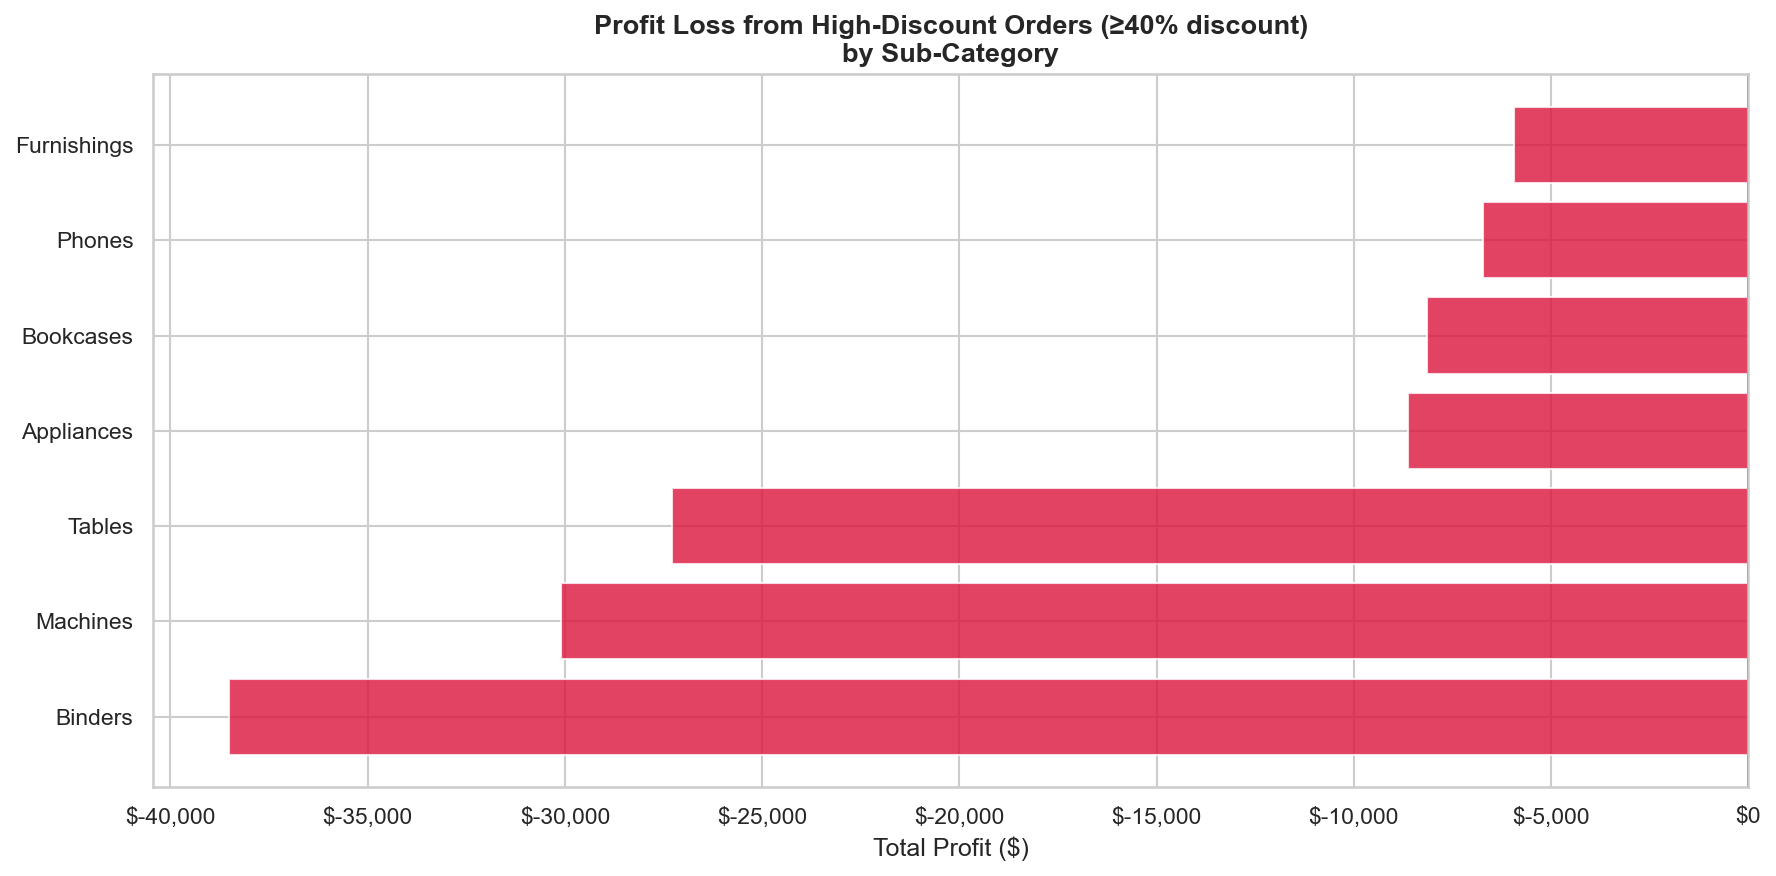

Saved.


In [8]:
# Visualise high-discount loss orders by sub-category
subcat_loss = (high_disc_loss.groupby("Sub-Category")["Profit"]
               .sum().sort_values().reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(subcat_loss["Sub-Category"], subcat_loss["Profit"],
        color="crimson", alpha=0.8, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Profit Loss from High-Discount Orders (≥40% discount)\nby Sub-Category",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Total Profit ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("../outputs/figures/high_discount_losses.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [9]:
# Save anomaly-flagged dataset
df.to_csv("../data/processed/anomaly_data.csv", index=False)
print("anomaly_data.csv saved to data/processed/")

# Final summary
print("\n=== ANOMALY DETECTION SUMMARY ===")
print(f"Total orders analysed:         {len(df):,}")
print(f"Total anomalies flagged:       {df['IsAnomaly'].sum():,}")
print(f"Anomaly rate:                  {df['IsAnomaly'].mean():.1%}")
print(f"Total profit loss (anomalies): ${df[df['IsAnomaly']]['Profit'].sum():,.2f}")
print(f"Total profit loss (all):       ${df[df['Profit']<0]['Profit'].sum():,.2f}")
print(f"\nMay 2016 spike: driven by large Technology orders")
print(f"Primary anomaly driver: high discounts (≥40%) on Furniture and Office Supplies")

anomaly_data.csv saved to data/processed/

=== ANOMALY DETECTION SUMMARY ===
Total orders analysed:         9,994
Total anomalies flagged:       2,175
Anomaly rate:                  21.8%
Total profit loss (anomalies): $137,888.26
Total profit loss (all):       $-156,131.29

May 2016 spike: driven by large Technology orders
Primary anomaly driver: high discounts (≥40%) on Furniture and Office Supplies
